In [1]:
"""
DIA_Deep2SP_main_ROI.py

Differential Imaging Attack (DIA) on experimental Deep2SP+ with an
ROI-weighted camouflage objective.

This script mirrors DIA_Deep2SP_main_full_image.py but:

  - Automatically extracts a 3D ROI around the main object from the
    clean Deep2SP+ reconstruction.
  - Computes the image loss ONLY inside this ROI (optionally with a
    small background term), so the attack focuses on erasing or
    reshaping the detected object while limiting global distortion.
"""

# ============================================================
# 0. Imports and basic setup
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from scipy.ndimage import label, binary_dilation

import src  # kept for consistency with other Deep2S scripts (not used directly)

tf.random.set_seed(0)
np.random.seed(0)

In [2]:
# ============================================================
# 1. Load measurements and attack dictionary
# ============================================================

# --- 1.1 Load clean experimental measurements y_clean ---
# y_exp: (K, T, R), complex-valued NF-SAR measurements
y_clean_path = "data/y_exp_test_4.npy"   # <-- adjust path if needed
y_exp = np.load(y_clean_path)           # (K, T, R), complex or complex-like
y_exp = y_exp.astype(np.complex64)

# Add batch dimension so Deep2SP+ sees shape (N, K, T, R)
y_clean = y_exp[None, ...]              # (1, K, T, R)
print("y_clean.shape =", y_clean.shape)

# Infer dimensions
_, K, T, R = y_clean.shape
Np = T * R                               # number of per-aperture DOFs (attack DOF)

# --- 1.2 Flatten measurements to (K, Np) for attack injection ---
X_v_flat = y_clean[0].reshape(K, Np)     # (K, Np)
X_v_flat_tf = tf.constant(X_v_flat, dtype=tf.complex64)

print("Flattened victim measurements X_v_flat shape:", X_v_flat.shape)

# --- 1.3 Load precomputed attack dictionary D_flat ---
D_flat_path = "data/D_flat.npy"          # <-- adjust path if needed
D_flat_np = np.load(D_flat_path)         # (K, Np), complex
assert D_flat_np.shape == X_v_flat.shape
D_flat_tf = tf.constant(D_flat_np.astype(np.complex64))

print("Loaded D_flat:", D_flat_np.shape)
print("y_clean.shape   =", y_clean.shape)
print("X_v_flat.shape  =", X_v_flat.shape)
print("D_flat.shape    =", D_flat_tf.shape)
print("Np (attack DOF) =", Np)

# TensorFlow constants used in the attack loop
y_clean_tf = tf.constant(y_clean)        # (1, K, T, R), complex64


y_clean.shape = (1, 15, 16, 9)
Flattened victim measurements X_v_flat shape: (15, 144)
Loaded D_flat: (15, 144)
y_clean.shape   = (1, 15, 16, 9)
X_v_flat.shape  = (15, 144)
D_flat.shape    = (15, 144)
Np (attack DOF) = 144


In [3]:
# ============================================================
# 2. Load Deep2SP+ DNN
# ============================================================

deep2sp_path = "models/experimental/Deep2S-Plus/model_Nf15_SNR30_Deep2SP_exp"
DNN = tf.keras.models.load_model(deep2sp_path, compile=False)
print("Loaded Deep2SP+ model from:", deep2sp_path)


Loaded Deep2SP+ model from: models/experimental/Deep2S-Plus/model_Nf15_SNR30_Deep2SP_exp


x_clean_mag.shape = (25, 25, 49)


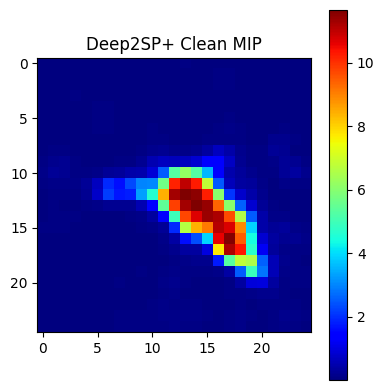

In [4]:
# ============================================================
# 3. Deep2SP+ forward operator: y -> DNN -> x_hat
# ============================================================

def deep2sp_forward_tf(y_batch: tf.Tensor) -> tf.Tensor:
    """
    Deep2SP+ forward mapping implemented in TensorFlow.

    Parameters
    ----------
    y_batch : tf.Tensor of shape (N, K, T, R), complex64
        Batch of complex-valued SAR measurements.

    Returns
    -------
    x_hat : tf.Tensor of shape (N, X, Y, Z), float32
        RMS-normalized reconstructed magnitude volumes.
    """
    # 1) Pack real and imaginary parts as 2 channels for Deep2SP+
    y_ri = tf.stack(
        [tf.math.real(y_batch), tf.math.imag(y_batch)],
        axis=-1
    )   # (N, K, T, R, 2)

    # 2) Predict 3D volume with the Deep2SP+ network
    x_hat = DNN(y_ri, training=False)    # (N, X, Y, Z, 1) or (N, X, Y, Z)

    # 3) Ensure real-valued output and remove trailing channel if present
    if tf.is_tensor(x_hat) and x_hat.dtype.is_complex:
        x_hat = tf.abs(x_hat)

    if len(x_hat.shape) == 5:
        x_hat = x_hat[..., 0]            # (N, X, Y, Z)

    # 4) RMS normalization: fix global scale to unit RMS per sample
    rms = tf.sqrt(
        tf.reduce_mean(x_hat**2, axis=(1, 2, 3), keepdims=True) + 1e-12
    )
    x_hat = x_hat / rms

    return x_hat  # (N, X, Y, Z), float32


# --- 3.1 Clean Deep2SP+ reconstruction (for reference) ---

x_clean_mag = deep2sp_forward_tf(y_clean_tf).numpy()[0]   # (X, Y, Z)
X, Y, Z = x_clean_mag.shape
print("x_clean_mag.shape =", x_clean_mag.shape)

clean_mip = x_clean_mag.max(axis=2)
plt.figure(figsize=(4, 4))
plt.imshow(clean_mip, origin="upper", cmap="jet")
plt.title("Deep2SP+ Clean MIP")
plt.colorbar()
plt.tight_layout()
plt.show()

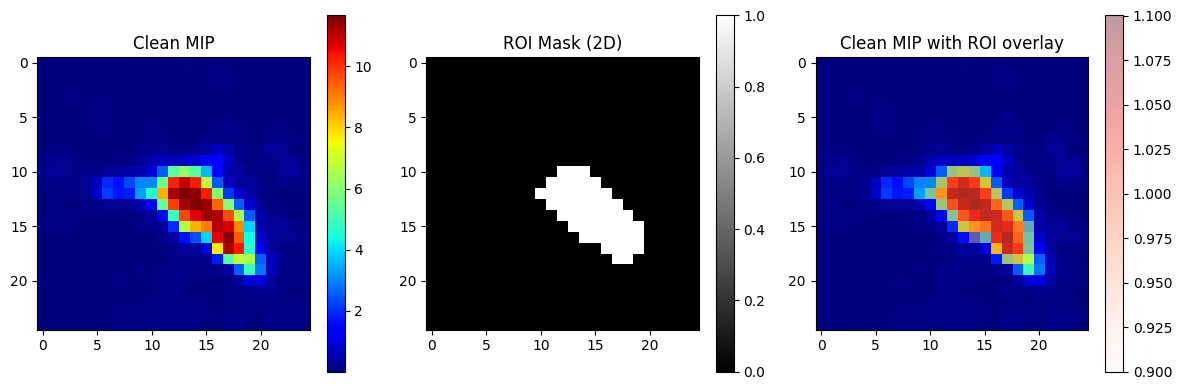

In [7]:
# ============================================================
# 4. Automatic 3D ROI mask around the main object
# ============================================================

# We detect the brightest blob in the 2D MIP, then lift it to 3D.
clean_mip = x_clean_mag.max(axis=2)   # (X, Y)

# 1) Threshold to get "bright" region
#    Tune 0.5–0.7 depending on how tight you want the ROI.
thresh = 0.7 * clean_mip.max()
binary = clean_mip > thresh           # (X, Y), bool

# 2) Connected components: keep the largest blob as the main object
labels, num = label(binary)
if num == 0:
    raise RuntimeError("No bright region found for ROI!")

counts = np.bincount(labels.ravel())
largest_label = np.argmax(counts[1:]) + 1
obj_mask_2d = (labels == largest_label)    # (X, Y), pixelwise mask

# 3) Optional dilation to give a small margin around the object
obj_mask_2d = binary_dilation(obj_mask_2d, iterations=1)

# 4) Lift to 3D ROI mask (same mask across all depths)
roi_mask = np.repeat(obj_mask_2d[..., None], Z, axis=2)   # (X, Y, Z), bool
roi_mask_tf = tf.constant(roi_mask)                       # TF bool mask

# Quick visualization of ROI
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(clean_mip, origin="upper", cmap="jet")
plt.title("Clean MIP")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(obj_mask_2d.astype(float), origin="upper", cmap="gray")
plt.title("ROI Mask (2D)")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(clean_mip, origin="upper", cmap="jet")
plt.imshow(
    np.ma.masked_where(obj_mask_2d == 0, obj_mask_2d),
    origin="upper", cmap="Reds", alpha=0.4
)
plt.title("Clean MIP with ROI overlay")
plt.colorbar()

plt.tight_layout()
plt.show()



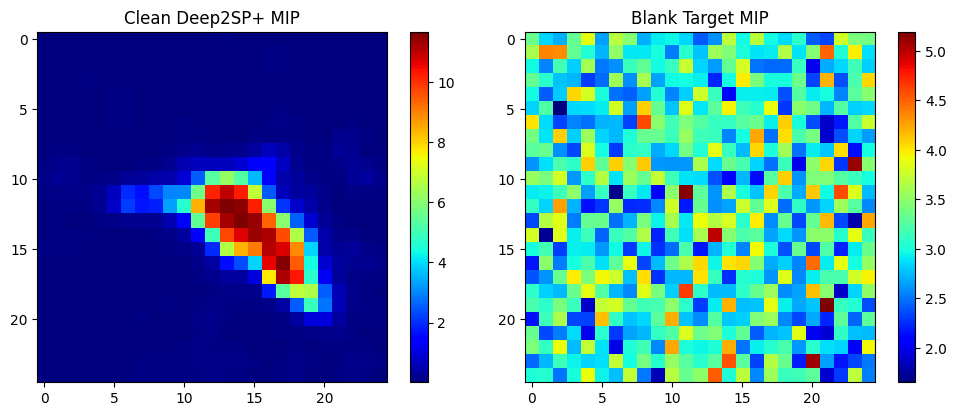

In [8]:
# ============================================================
# 5. Construct "blank" target volume (same as full-image case)
# ============================================================

# We still define a global background-like target volume; the loss
# will only be enforced inside the ROI (plus optional small background).

clean_mip = x_clean_mag.max(axis=2)
bg_val = float(clean_mip[0, 0])
drange = float(clean_mip.max() - clean_mip.min())

base = np.full((X, Y, Z), bg_val, dtype=np.float32)

np.random.seed(1234)
noise_std = 0.05 * drange
noise = noise_std * np.random.randn(X, Y, Z).astype(np.float32)

x_target = base + noise
x_target = np.clip(x_target, 0.0, None)

rms_tgt = np.sqrt(np.mean(x_target**2) + 1e-12)
x_target = x_target / rms_tgt

x_target_tf = tf.constant(x_target[None, ...])      # (1, X, Y, Z)
x_target_mip = x_target.max(axis=2)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(clean_mip, origin="upper", cmap="jet")
plt.title("Clean Deep2SP+ MIP")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(x_target_mip, origin="upper", cmap="jet")
plt.title("Blank Target MIP")
plt.colorbar()

plt.tight_layout()
plt.show()


In [10]:
# ============================================================
# 6. Attack loss: ROI-weighted MSE + optional BG + L2 on A
# ============================================================

def attack_loss(A_re: tf.Tensor,
                A_im: tf.Tensor,
                lambda_L2: float = 0.0,
                roi_weight: float = 1.0,
                bg_weight: float = 0.0):
    """
    ROI-weighted DIA objective for Deep2SP+:

        L = roi_weight * MSE_ROI(x_att, x_target)
          + bg_weight  * MSE_BG(x_att, x_target)
          + lambda_L2  * ||A||_2^2

    where:
      - MSE_ROI is computed only inside the 3D ROI mask.
      - MSE_BG is computed on the complement (optional).
    """
    # Complex gains A_p (Np,)
    A_complex = tf.complex(A_re, A_im)
    A_col = tf.reshape(A_complex, (1, Np))          # (1, Np)

    # Attacked measurements (K, Np)
    Y_flat = X_v_flat_tf + D_flat_tf * A_col        # (K, Np)

    # Reshape back to (1, K, T, R)
    Y_batch = tf.reshape(Y_flat, (1, K, T, R))      # (1, K, T, R)

    # Deep2SP+ reconstruction from attacked data
    x_hat_mag = deep2sp_forward_tf(Y_batch)         # (1, X, Y, Z)
    x_hat = x_hat_mag[0]                            # (X, Y, Z)
    x_tgt = x_target_tf[0]                          # (X, Y, Z)

    # ROI / background masks
    roi_mask_local = roi_mask_tf                   # (X, Y, Z), bool
    bg_mask_local = tf.logical_not(roi_mask_local)

    # ROI MSE
    roi_diff = tf.boolean_mask(x_hat - x_tgt, roi_mask_local)
    mse_roi = tf.reduce_mean(roi_diff**2)

    # Background MSE (optional)
    bg_diff = tf.boolean_mask(x_hat - x_tgt, bg_mask_local)
    mse_bg = tf.reduce_mean(bg_diff**2)

    loss_im = roi_weight * mse_roi + bg_weight * mse_bg

    # ℓ2 regularization on A
    reg = lambda_L2 * tf.reduce_mean(tf.abs(A_complex)**2)

    loss = loss_im + reg
    return loss, loss_im, reg, x_hat_mag

In [11]:
# ============================================================
# 7. DIA loop with tanh-parameterized A (ROI loss)
# ============================================================

Amax = 2.0          # physical bound on |A_p|
lambda_L2 = 1e-5    # ℓ2 weight (can tune 1e-4–1e-2)
max_iter = 300      # number of gradient steps

# Latent variables Z; A will be obtained via smooth tanh mapping
Z_re = tf.Variable(1e-3 * tf.random.normal(shape=(Np,), dtype=tf.float32))
Z_im = tf.Variable(1e-3 * tf.random.normal(shape=(Np,), dtype=tf.float32))

def get_A_from_Z(Z_re: tf.Tensor, Z_im: tf.Tensor, Amax: float = 2.0):
    """
    Smooth parameterization of complex gains:
        A_re = (Amax / sqrt(2)) * tanh(Z_re)
        A_im = (Amax / sqrt(2)) * tanh(Z_im)
    guaranteeing |A_p| <= Amax without explicit clipping.
    """
    scale = Amax / np.sqrt(2.0)
    A_re = scale * tf.tanh(Z_re)
    A_im = scale * tf.tanh(Z_im)
    return A_re, A_im

# Adam optimizer with 2-stage LR schedule
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-1)
lr_switch_iter = 100
low_lr = 1e-2

loss_hist = []
meanA_hist = []
maxA_hist = []

print("\nStarting ROI-based DIA optimization on Deep2SP+ (Np = {})...".format(Np))

for it in range(1, max_iter + 1):

    if it == lr_switch_iter + 1:
        optimizer.learning_rate.assign(low_lr)
        print(f"\n[LR SCHEDULE] Switched Adam LR to {low_lr}\n")

    with tf.GradientTape() as tape:
        A_re_cur, A_im_cur = get_A_from_Z(Z_re, Z_im, Amax=Amax)
        loss_total, loss_im, reg, x_hat_mag = attack_loss(
            A_re_cur, A_im_cur,
            lambda_L2=lambda_L2,
            roi_weight=1.0,
            bg_weight=0.0   # set >0 if you want a background term
        )

    grads = tape.gradient(loss_total, [Z_re, Z_im])
    optimizer.apply_gradients(zip(grads, [Z_re, Z_im]))

    # Logging statistics
    A_re_val, A_im_val = get_A_from_Z(Z_re, Z_im, Amax=Amax)
    A_complex = tf.complex(A_re_val, A_im_val)
    A_now = A_complex.numpy()
    meanA = np.mean(np.abs(A_now))
    maxA = np.max(np.abs(A_now))

    loss_hist.append(loss_total.numpy().item())
    meanA_hist.append(meanA)
    maxA_hist.append(maxA)

    if (it == 1) or (it % 5 == 0) or (it == max_iter):
        print(
            f"Iter {it:3d}/{max_iter:3d} | "
            f"Loss={loss_total.numpy():.6e} | "
            f"loss_im={loss_im.numpy():.6e} | reg={reg.numpy():.6e} | "
            f"mean|A|={meanA:.3e}, max|A|={maxA:.3e}"
        )

print("ROI-based attack optimization finished.")



Starting ROI-based DIA optimization on Deep2SP+ (Np = 144)...
Iter   1/300 | Loss=1.150679e+01 | loss_im=1.150679e+01 | reg=4.336306e-11 | mean|A|=9.226e-01, max|A|=9.265e-01
Iter   5/300 | Loss=1.137252e+01 | loss_im=1.137250e+01 | reg=1.975045e-05 | mean|A|=1.433e+00, max|A|=1.957e+00
Iter  10/300 | Loss=5.911191e+00 | loss_im=5.911163e+00 | reg=2.857811e-05 | mean|A|=1.688e+00, max|A|=1.997e+00
Iter  15/300 | Loss=2.562007e+00 | loss_im=2.561974e+00 | reg=3.265285e-05 | mean|A|=1.804e+00, max|A|=2.000e+00
Iter  20/300 | Loss=1.483744e+00 | loss_im=1.483709e+00 | reg=3.511371e-05 | mean|A|=1.876e+00, max|A|=2.000e+00
Iter  25/300 | Loss=1.247170e+00 | loss_im=1.247134e+00 | reg=3.660035e-05 | mean|A|=1.909e+00, max|A|=2.000e+00
Iter  30/300 | Loss=1.088214e+00 | loss_im=1.088177e+00 | reg=3.746305e-05 | mean|A|=1.935e+00, max|A|=2.000e+00
Iter  35/300 | Loss=1.037074e+00 | loss_im=1.037036e+00 | reg=3.820487e-05 | mean|A|=1.953e+00, max|A|=2.000e+00
Iter  40/300 | Loss=1.021624e+00 

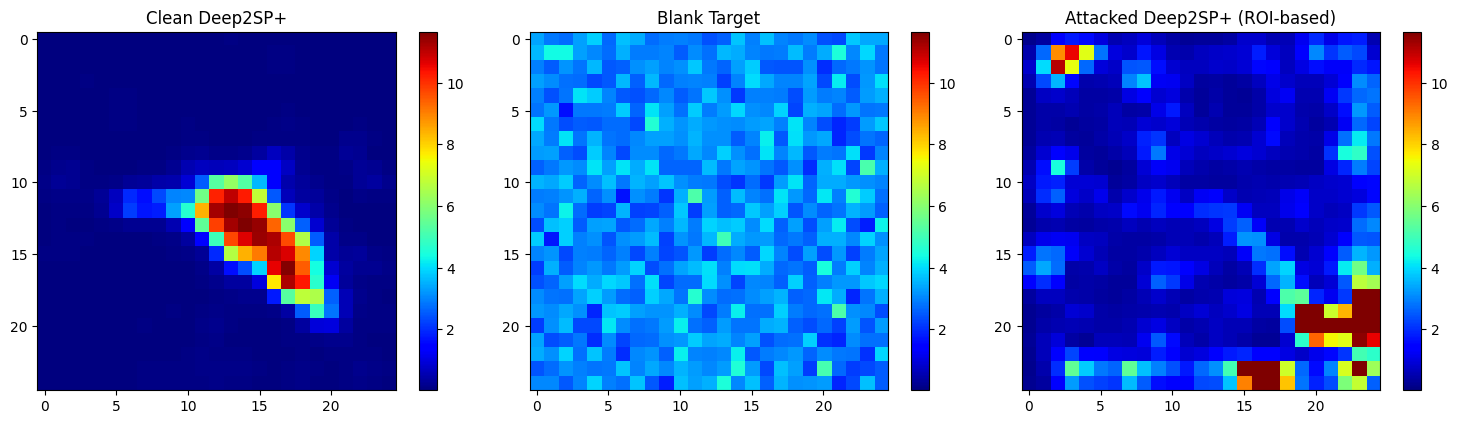

In [12]:
# ============================================================
# 8. Final attacked reconstruction and visualization
# ============================================================

A_re_opt, A_im_opt = get_A_from_Z(Z_re, Z_im, Amax=Amax)
A_opt_tf = tf.complex(A_re_opt, A_im_opt)          # (Np,)
A_opt_col = tf.reshape(A_opt_tf, (1, Np))          # (1, Np)

Y_opt_flat_tf = X_v_flat_tf + D_flat_tf * A_opt_col
Y_opt_tf = tf.reshape(Y_opt_flat_tf, (1, K, T, R))

x_att_mag = deep2sp_forward_tf(Y_opt_tf).numpy()[0]   # (X, Y, Z)

clean_mip = x_clean_mag.max(axis=2)
att_mip = x_att_mag.max(axis=2)
target_mip = x_target.max(axis=2)

vmin = clean_mip.min()
vmax = clean_mip.max()

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(clean_mip, origin="upper", cmap="jet", vmin=vmin, vmax=vmax)
plt.title("Clean Deep2SP+")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(target_mip, origin="upper", cmap="jet", vmin=vmin, vmax=vmax)
plt.title("Blank Target")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(att_mip, origin="upper", cmap="jet", vmin=vmin, vmax=vmax)
plt.title("Attacked Deep2SP+ (ROI-based)")
plt.colorbar()

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 9. Global MIP-level metrics + ROI-only 3D metrics
# ============================================================

# --- 9.1 Global MIP-level metrics (just for reference) ---
mse_mip = np.mean((att_mip - target_mip) ** 2)
rmse_mip = np.sqrt(mse_mip)
mae_mip = np.mean(np.abs(att_mip - target_mip))

num = np.sum(att_mip * target_mip)
den = np.sqrt(np.sum(att_mip**2) * np.sum(target_mip**2)) + 1e-12
ncc_mip = num / den

data_range = float(target_mip.max() - target_mip.min() + 1e-12)
ssim_mip = ssim(att_mip, target_mip, data_range=data_range)
psnr_mip = psnr(target_mip, att_mip, data_range=data_range)

print("\n--- Global MIP-level attack metrics (Deep2SP+, ROI-trained) ---")
print(f"MSE   : {mse_mip:.4e}")
print(f"RMSE  : {rmse_mip:.4e}")
print(f"MAE   : {mae_mip:.4e}")
print(f"NCC   : {ncc_mip:.4f}")
print(f"SSIM  : {ssim_mip:.4f}")
print(f"PSNR  : {psnr_mip:.2f} dB")

# --- 9.2 ROI-only 3D MSE (clean vs target, attacked vs target) ---
roi_bool = roi_mask.astype(bool)

clean_roi = x_clean_mag[roi_bool]
att_roi = x_att_mag[roi_bool]
tgt_roi = x_target[roi_bool]

mse_clean_roi = np.mean((clean_roi - tgt_roi) ** 2)
mse_att_roi = np.mean((att_roi - tgt_roi) ** 2)

print("\n--- ROI-level (3D) MSE ---")
print(f"Clean vs target (ROI):    {mse_clean_roi:.4e}")
print(f"Attacked vs target (ROI): {mse_att_roi:.4e}")

# Loss curve
plt.figure(figsize=(5, 4))
plt.plot(loss_hist)
plt.xlabel("Iteration")
plt.ylabel("Total loss")
plt.title("ROI-based DIA Loss (Deep2SP+)")
plt.tight_layout()
plt.show()